# Lightweight Attentive Residual U-Net (LAR-U-Net) Image Denoising


In [1]:
!pip install -q torch torchvision matplotlib pillow

import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')

PyTorch version : 2.10.0+cu128
CUDA available  : True


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")

print("Path to dataset files:", path)

100%|██████████| 56.0M/56.0M [00:04<00:00, 14.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/versions/1


In [6]:
import os, gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

SIGMA      = 25
BATCH_SIZE = 8
EPOCHS     = 10
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths — confirmed correct structure
base       = "/root/.cache/kagglehub/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/versions/1"
train_path = os.path.join(base, "images", "train")
val_path   = os.path.join(base, "images", "val")
test_path  = os.path.join(base, "images", "test")

for name, p in [("train", train_path), ("val", val_path), ("test", test_path)]:
    count = len([f for f in os.listdir(p) if f.endswith(".jpg")])
    print(f"{name}: {count} images")

print(f"Device: {device}")

train: 200 images
val: 100 images
test: 200 images
Device: cuda


# Dataset Class

In [8]:
class BSDS500Denoise(Dataset):
    def __init__(self, root_dir, sigma=25):
        self.root_dir    = root_dir
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(('.jpg', '.png'))]
        self.sigma       = sigma / 255.0
        self.transform   = transforms.Compose([
            transforms.CenterCrop(128),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path  = os.path.join(self.root_dir, self.image_files[idx])
        clean_img = self.transform(Image.open(img_path).convert('L'))
        noise     = torch.randn(clean_img.size()) * self.sigma
        noisy_img = (clean_img + noise).clamp(0, 1)
        return noisy_img, clean_img

# Sanity check
ds      = BSDS500Denoise(train_path, sigma=SIGMA)
noisy, clean    = ds[0]
print(f'Sample shape : noisy={noisy.shape}  clean={clean.shape}')

Sample shape : noisy=torch.Size([1, 128, 128])  clean=torch.Size([1, 128, 128])


# Proposed Denoising Model: LAR-U-Net
---
### Lightweight Attentive Residual U-Net

The **LAR-U-Net** is an advanced image restoration architecture that combines the spatial precision of **U-Nets**, the feature refinement of **Attention Modules**, and residual learning strategies.

---

## 1. The Input: Gradient-Augmented Processing

Instead of feeding only the raw noisy image $I$, the model utilizes **Gradient-Augmented Processing**. We compute the image gradients to highlight structural edges, which are then concatenated with the original image.

* **Operation**: Using **Sobel Filters** to calculate horizontal ($G_x$) and vertical ($G_y$) gradients.
* **Math**: The gradient magnitude $G$ is given by:

$$G = \sqrt{G_x^2 + G_y^2}$$


* **Why**: This forces the model to recognize "edges" immediately, preventing the **over-smoothing** common in basic CNN-based denoisers.

---

## 2. The Backbone: U-Net with Skip Connections

The architecture adopts the **Symmetric Encoder-Decoder** design of a U-Net to maintain high-resolution spatial data.

* **Kernel Choice**: Strictly **3x3 kernels** are used. Research suggests this is the optimal balance between error reduction and model fit ($O(k^2)$ complexity).

*
**Skip Connections**: These bridge the encoder and decoder, ensuring that fine details lost during the compression layers are recovered during upsampling.

**Residual Units**: The network is built with residual units which ease training and facilitate information propagation.



---

## 3. Simple Attention Blocks (CBAM)

To prioritize important features, a **Convolutional Block Attention Module (CBAM)** is inserted into each encoder layer.

*
**Channel Attention**: Identifies *which* feature maps contain the most relevant signal (vs. noise).


*
**Spatial Attention**: Identifies *where* the noise is most destructive in the spatial grid.


* **Math**: The final refined feature $F''$ is derived as:

$$F' = M_c(F) \otimes F$$


$$F'' = M_s(F') \otimes F'$$



> Where $M_c$ is the Channel Attention map and $M_s$ is the Spatial Attention map.
>
>


---

## 4. The Output: Residual Learning Strategy

Following the **DnCNN** paradigm, the model does not attempt to reconstruct the clean image directly. Instead, it predicts the **Noise Map** $\mathcal{R}(y)$.

*
**Mechanism**: The predicted noise is subtracted from the original noisy input.



$$\hat{x} = y - \mathcal{R}(y)$$


*
**Advantage**: It is mathematically easier to "find the noise" than to rebuild the clean image from scratch, leading to faster convergence and better stability.

---

### Optimization Function

The model is typically trained using a **Loss Function**  (MSE):


$$\mathcal{L} = || (y_i - \text{LAR-U-Net}(y_i)) - x_i ||^2$$


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_sobel_gradients(image):
    """Sobel edge detection. Uses image.device"""
    dev = image.device
    kx  = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], device=dev).view(1,1,3,3).float()
    ky  = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], device=dev).view(1,1,3,3).float()
    return F.conv2d(image, kx, padding=1), F.conv2d(image, ky, padding=1)


class CBAM(nn.Module):
    """Convolutional Block Attention Module"""
    def __init__(self, channels):
        super().__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 8, 1),
            nn.ReLU(),
            nn.Conv2d(channels // 8, channels, 1),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(
            nn.Conv2d(2, 1, 7, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x * self.ca(x)
        s = torch.cat([torch.mean(x, 1, keepdim=True),
                       torch.max(x,  1, keepdim=True)[0]], dim=1)
        return x * self.sa(s)

class PreActResidualUnit(nn.Module):
    """
    Implements a Full Pre-activation Residual Unit: BN -> ReLU -> Conv
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(PreActResidualUnit, self).__init__()

        # Branch 1: Pre-activated Residual Function
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

        # Branch 2: Shortcut Connection (Identity Mapping)
        # If dimensions change (stride > 1 or channel mismatch), apply a 1x1 conv to match.
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # Apply pre-activation
        pre_act = self.relu(self.bn1(x))

        # Residual signal
        out = self.conv1(pre_act)
        out = self.conv2(self.relu(self.bn2(out)))

        # Combine with identity shortcut
        return out + self.shortcut(x)

class LAR_UNet(nn.Module):
    """
    Enhanced LAR-U-Net integrating Deep Residual Learning and CBAM.
    Replaces Max-Pooling with Strided Convolutions for better feature retention.
    """
    def __init__(self, in_nc=1, out_nc=1, features=64):
        super(LAR_UNet, self).__init__()

        # Initial Gradient Augmentation (from LAR-U-Net original design)
        # Input is 3 channels: Grayscale + Gx + Gy
        self.init_conv = nn.Conv2d(3, features, kernel_size=3, padding=1)

        # Encoder Path
        self.enc_block1 = PreActResidualUnit(features, features)
        self.att1 = CBAM(features)

        # Downsampling via stride=2 convolution in the residual unit
        self.enc_block2 = PreActResidualUnit(features, features * 2, stride=2)
        self.att2 = CBAM(features * 2)

        # Bridge (Bottleneck)
        self.bridge = PreActResidualUnit(features * 2, features * 4, stride=2)

        # Decoder Path
        self.up1 = nn.ConvTranspose2d(features * 4, features * 2, kernel_size=2, stride=2)
        self.dec_block1 = PreActResidualUnit(features * 4, features * 2) # Concat + Residual

        self.up2 = nn.ConvTranspose2d(features * 2, features, kernel_size=2, stride=2)
        self.dec_block2 = PreActResidualUnit(features * 2, features) # Concat + Residual

        # Final Noise Prediction (Residual Learning Strategy)
        self.final = nn.Conv2d(features, out_nc, kernel_size=1)

    def forward(self, y):
        # 1. Gradient-Augmented Input Processing
        gx, gy = get_sobel_gradients(y)
        x = torch.cat([y, gx, gy], dim=1)
        x = self.init_conv(x)

        # 2. Encoding Path (with Skip Connections)
        e1 = self.att1(self.enc_block1(x))
        e2 = self.att2(self.enc_block2(e1))

        # 3. Bridge
        b = self.bridge(e2)

        # 4. Decoding Path (Concatenation)
        d1 = self.up1(b)
        d1 = self.dec_block1(torch.cat([d1, e2], dim=1))

        d2 = self.up2(d1)
        d2 = self.dec_block2(torch.cat([d2, e1], dim=1))

        # 5. Output: Subtract predicted noise from noisy input
        noise_map = self.final(d2)
        return y - noise_map



# Quick check
with torch.no_grad():
    _m   = LAR_UNet()
    _inp = torch.randn(1, 1, 128, 128)
    _out = _m(_inp)
    print(f'Model check: {_inp.shape} → {_out.shape}')
    del _m, _inp, _out

Model check: torch.Size([1, 1, 128, 128]) → torch.Size([1, 1, 128, 128])


# Training

In [10]:
torch.cuda.empty_cache()
gc.collect()

loader_train = DataLoader(BSDS500Denoise(train_path, sigma=SIGMA), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
loader_val   = DataLoader(BSDS500Denoise(val_path,   sigma=SIGMA), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
loader_test  = DataLoader(BSDS500Denoise(test_path,  sigma=SIGMA), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(loader_train)} batches | Val: {len(loader_val)} batches | Test: {len(loader_test)} batches')

model = LAR_UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

t_hist, v_history = [], []

print(f'\nTraining on {device}...\n')

for epoch in range(EPOCHS):
    # Train Loop
    model.train()
    t_loss = 0
    for noisy, clean in loader_train:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        loss = criterion(model(noisy), clean)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    # Validate Loop
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for noisy, clean in loader_val:
            noisy, clean = noisy.to(device), clean.to(device)
            v_loss += criterion(model(noisy), clean).item()

    tl = t_loss / len(loader_train)
    vl = v_loss / len(loader_val)
    t_hist.append(tl)
    v_history.append(vl)
    print(f'Epoch {epoch+1:02d}/{EPOCHS}  |  Train: {tl:.5f}  |  Val: {vl:.5f}')

# Test Loop
model.eval()
test_mae = 0
with torch.no_grad():
    for noisy, clean in loader_test:
        noisy, clean = noisy.to(device), clean.to(device)
        test_mae += F.l1_loss(model(noisy), clean).item()

print(f'\nTest MAE: {test_mae / len(loader_test):.5f}')
print('Training complete!')

Train: 25 batches | Val: 13 batches | Test: 25 batches

Training on cuda...

Epoch 01/10  |  Train: 0.22759  |  Val: 0.24682
Epoch 02/10  |  Train: 0.00983  |  Val: 0.00924
Epoch 03/10  |  Train: 0.00526  |  Val: 0.00506
Epoch 04/10  |  Train: 0.00454  |  Val: 0.00455
Epoch 05/10  |  Train: 0.00415  |  Val: 0.00414
Epoch 06/10  |  Train: 0.00387  |  Val: 0.00390
Epoch 07/10  |  Train: 0.00361  |  Val: 0.00371
Epoch 08/10  |  Train: 0.00343  |  Val: 0.00351
Epoch 09/10  |  Train: 0.00327  |  Val: 0.00337
Epoch 10/10  |  Train: 0.00315  |  Val: 0.00327

Test MAE: 0.04253
Training complete!


### **PSNR (Peak Signal-to-Noise Ratio)**

In the context of **Computer Vision** and **Image Processing**, **Peak Signal-to-Noise Ratio (PSNR)** is a standard engineering metric used to quantify the quality of reconstruction (e.g., denoising, compression, or super-resolution) relative to the original "ground truth" data. It represents the ratio between the maximum possible power of a signal and the power of corrupting noise.

---

### **The Mathematical Foundation**

To calculate PSNR, we must first compute the **Mean Squared Error (MSE)**, which measures the average squared difference between the original image $I$ and the reconstructed image $K$ of size $m \times n$.

**1. Mean Squared Error (MSE):**
$$MSE = \frac{1}{mn} \sum_{i=0}^{m-1} \sum_{j=0}^{n-1} [I(i,j) - K(i,j)]^2$$

**2. Peak Signal-to-Noise Ratio (PSNR):**
$$PSNR = 10 \cdot \log_{10} \left( \frac{MAX_I^2}{MSE} \right)$$

*   **$MAX_I$**: The maximum possible pixel value of the image (e.g., **255** for 8-bit grayscale/RGB images).
*   **Logarithmic Scale**: PSNR is expressed in **decibels (dB)**. Because it uses a log scale, small numerical changes in dB represent significant differences in image quality.

> **Illustrative Example:**
> If you have a clean image $I$ and a denoised image $K$ where the $MSE = 0$ (perfect reconstruction), the $PSNR$ becomes infinite ($\infty$). If $MSE = 1$ and $MAX_I = 255$, the $PSNR \approx 48.13 \text{ dB}$.

---

### **Impact of Value Changes**

The relationship between PSNR and image quality is **inverse** to the error ($MSE$).

*   **Increasing PSNR ($\uparrow$):**
    *   Indicates that the **Mean Squared Error ($MSE$)** is **decreasing**.
    *   **Result**: The reconstructed image is closer to the original. Higher values (typically **30dB to 50dB** for 8-bit images) signify high-quality restoration with minimal visible artifacts.
*   **Decreasing PSNR ($\downarrow$):**
    *   Indicates that the **Mean Squared Error ($MSE$)** is **increasing**.
    *   **Result**: The image contains more noise, blurring, or compression artifacts. Values below **20dB** are generally considered poor quality and visually distorted.


---

### **Pros and Cons**

**Advantages (Pros):**
*   **Mathematical Simplicity**: Extremely easy and fast to calculate during the training of models like **LAR-U-Net**.
*   **Standardization**: It is the universal benchmark in academic literature for comparing denoising algorithms.
*   **Clear Optimization Target**: Minimizing $MSE$ (which maximizes $PSNR$) is a convex problem, making it stable for gradient descent.

**Disadvantages (Cons):**
*   **Poor Perceptual Correlation**: An image with a high PSNR can still look "blurry" or "fake" to a human because PSNR treats all pixel differences equally, regardless of whether they occur on an edge or a flat background.
*   **Sensitivity to Shifts**: Even a slight spatial shift of 1 pixel can cause a massive drop in PSNR, even if the image looks identical to the human eye.

## Visualization

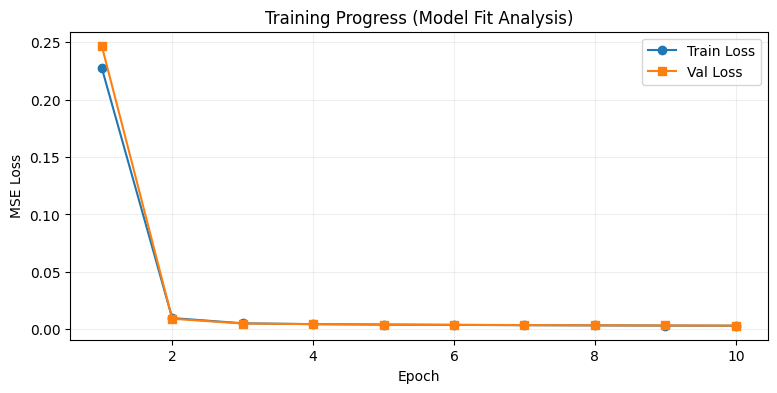


--- PERFORMANCE STATS: SAMPLE 1 ---
PSNR Before: 20.21 dB
PSNR After:  28.01 dB
Improvement: +7.79 dB
MAE Before:  0.0779
MAE After:   0.0306

--- PERFORMANCE STATS: SAMPLE 2 ---
PSNR Before: 20.19 dB
PSNR After:  27.36 dB
Improvement: +7.18 dB
MAE Before:  0.0783
MAE After:   0.0331


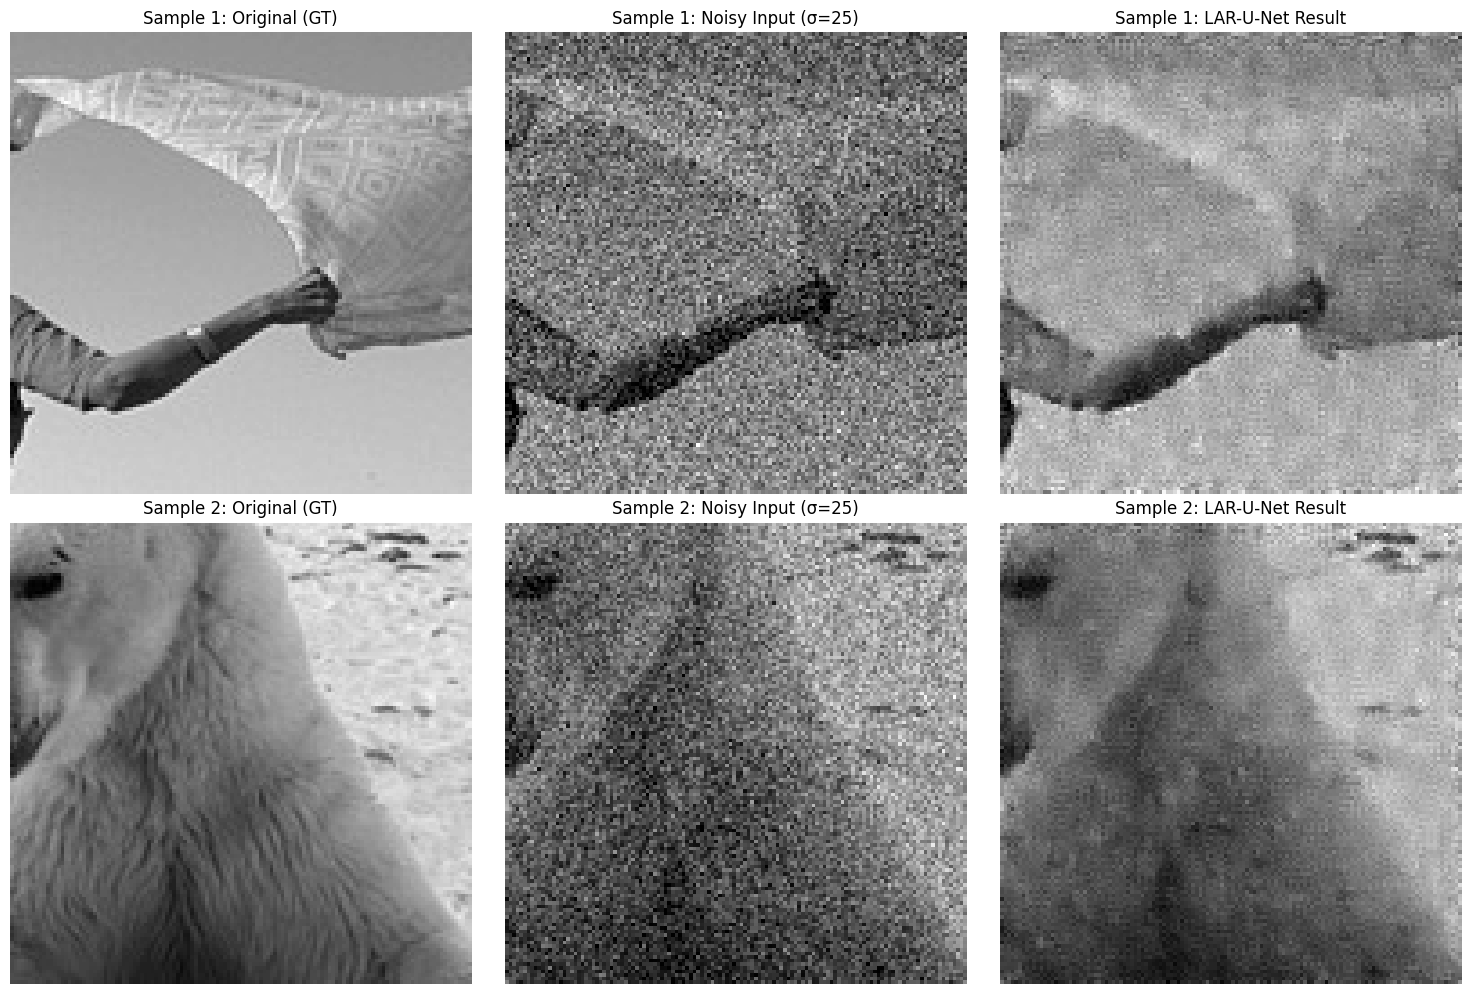

52684

In [21]:
model.to('cpu')
torch.cuda.empty_cache()
gc.collect()
model.eval()

# Helper for objective evaluation metrics
def get_metrics(target, predicted):
    mse = np.mean((target - predicted) ** 2)
    psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')
    mae = np.mean(np.abs(target - predicted))
    return psnr, mae

# 1. Loss Curve
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), t_hist, marker='o', label='Train Loss')
plt.plot(range(1, EPOCHS+1), v_history, marker='s', label='Val Loss')
plt.title('Training Progress (Model Fit Analysis)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('loss_curve.png', bbox_inches='tight', dpi=300)
plt.show()

# 2. Two-Sample Denoising Comparison
# Grab two different batches for variety
iterator = iter(loader_test)
num_samples = 2
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 10))

for i in range(num_samples):
    noisy_batch, clean_batch = next(iterator)

    with torch.no_grad(): # Disable gradient history to save system RAM
        output = model(noisy_batch[0:1])

    # Standardize data for evaluation
    img_gt    = clean_batch[0].squeeze().numpy().clip(0, 1)
    img_noisy = noisy_batch[0].squeeze().numpy().clip(0, 1)
    img_res   = output[0].squeeze().numpy().clip(0, 1)

    # Compute Metrics
    p_before, m_before = get_metrics(img_gt, img_noisy)
    p_after, m_after   = get_metrics(img_gt, img_res)
    improvement = p_after - p_before

    # Plot Row i
    axes[i, 0].imshow(img_gt, cmap='gray'); axes[i, 0].set_title(f"Sample {i+1}: Original (GT)")
    axes[i, 1].imshow(img_noisy, cmap='gray'); axes[i, 1].set_title(f"Sample {i+1}: Noisy Input (σ={SIGMA})")
    axes[i, 2].imshow(img_res, cmap='gray'); axes[i, 2].set_title(f"Sample {i+1}: LAR-U-Net Result")
    for ax in axes[i]: ax.axis('off')

    # 3. Plain Text Metrics Output
    print(f"\n--- PERFORMANCE STATS: SAMPLE {i+1} ---")
    print(f"PSNR Before: {p_before:.2f} dB")
    print(f"PSNR After:  {p_after:.2f} dB")
    print(f"Improvement: {improvement:+.2f} dB") # Positive gain proves residual learning efficacy
    print(f"MAE Before:  {m_before:.4f}")
    print(f"MAE After:   {m_after:.4f}")

plt.tight_layout()
plt.savefig('denoised_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

# Final cleanup
del output
gc.collect()

# Download Multi-Noise Dataset

In [12]:
import kagglehub, os

noise_path = kagglehub.dataset_download("goutham1208/multi-noises-for-image-denoising")
print(f"Downloaded to: {noise_path}")

# check structure
for root, dirs, files in os.walk(noise_path):
    level = root.replace(noise_path, "").count(os.sep)
    if level < 5:
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
        imgs = [f for f in files if f.endswith((".jpg", ".png"))]
        if imgs:
            print(f"{indent}  → {len(imgs)} images")

100%|██████████| 355M/355M [00:23<00:00, 15.8MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/goutham1208/multi-noises-for-image-denoising/versions/1
1/
  dataset/
    original/
      → 300 images
    noises/
      gaussian/
        → 300 images
      quantization/
        → 300 images
      speckle/
        → 300 images
      jpeg/
        → 300 images
      salt_and_pepper/
        → 300 images
      poisson/
        → 300 images
      multiplicative/
        → 300 images


## Test Model on All Noise Types (except Gaussian)

In [13]:
import os, torch, numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

base_noise = "/root/.cache/kagglehub/datasets/goutham1208/multi-noises-for-image-denoising/versions/1/dataset"
orig_path  = os.path.join(base_noise, "original")

# All noise types except Gaussian
noise_types = {
    "Salt & Pepper"    : os.path.join(base_noise, "noises", "salt_and_pepper"),
    "Quantization"     : os.path.join(base_noise, "noises", "quantization"),
    "Speckle"          : os.path.join(base_noise, "noises", "speckle"),
    "Multiplicative"   : os.path.join(base_noise, "noises", "multiplicative"),
    "Poisson"          : os.path.join(base_noise, "noises", "poisson"),
    "JPEG"             : os.path.join(base_noise, "noises", "jpeg"),
}

transform = transforms.Compose([
    transforms.CenterCrop(128),
    transforms.Grayscale(),
    transforms.ToTensor(),
])

def load_image(folder, filename):
    return transform(Image.open(os.path.join(folder, filename)))

def compute_psnr(clean, denoised):
    mse = np.mean((clean - denoised) ** 2)
    return 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

def compute_mae(clean, denoised):
    return np.mean(np.abs(clean - denoised))

# Find common files across all folders
orig_files = sorted([f for f in os.listdir(orig_path) if f.endswith((".jpg", ".png"))])
common     = sorted(set(orig_files) & set.intersection(*[
    set(os.listdir(p)) for p in noise_types.values()
]))
print(f"Matched image pairs: {len(common)}")

# Run model
model.to('cpu')
model.eval()

results = {name: {"psnr_before": [], "psnr_after": [], "mae_before": [], "mae_after": []}
           for name in noise_types}

with torch.no_grad():
    for fname in common[:50]:
        clean    = load_image(orig_path, fname)
        clean_np = clean.squeeze().numpy().clip(0, 1)

        for name, folder in noise_types.items():
            noisy      = load_image(folder, fname)
            denoised   = model(noisy.unsqueeze(0)).squeeze(0)
            noisy_np   = noisy.squeeze().numpy().clip(0, 1)
            denoised_np = denoised.squeeze().numpy().clip(0, 1)

            results[name]["psnr_before"].append(compute_psnr(clean_np, noisy_np))
            results[name]["psnr_after"].append(compute_psnr(clean_np, denoised_np))
            results[name]["mae_before"].append(compute_mae(clean_np, noisy_np))
            results[name]["mae_after"].append(compute_mae(clean_np, denoised_np))

# Print summary table
print(f"\n{'Noise Type':<18} {'PSNR Before':>12} {'PSNR After':>11} {'Improvement':>12} {'MAE Before':>11} {'MAE After':>10}")
print("-" * 80)
for name, r in results.items():
    pb  = np.mean(r["psnr_before"])
    pa  = np.mean(r["psnr_after"])
    mb  = np.mean(r["mae_before"])
    ma  = np.mean(r["mae_after"])
    print(f"{name:<18} {pb:>11.2f}  {pa:>10.2f}  {pa-pb:>+11.2f}  {mb:>10.4f}  {ma:>10.4f}")

Matched image pairs: 300

Noise Type          PSNR Before  PSNR After  Improvement  MAE Before  MAE After
--------------------------------------------------------------------------------
Salt & Pepper            18.17       21.86        +3.70      0.0294      0.0414
Quantization             23.75       23.00        -0.75      0.0597      0.0631
Speckle                  30.04       29.72        -0.32      0.0246      0.0253
Multiplicative           17.26       20.81        +3.55      0.1062      0.0705
Poisson                  31.15       30.06        -1.09      0.0218      0.0243
JPEG                     32.95       29.81        -3.14      0.0174      0.0248


## Visual Comparison


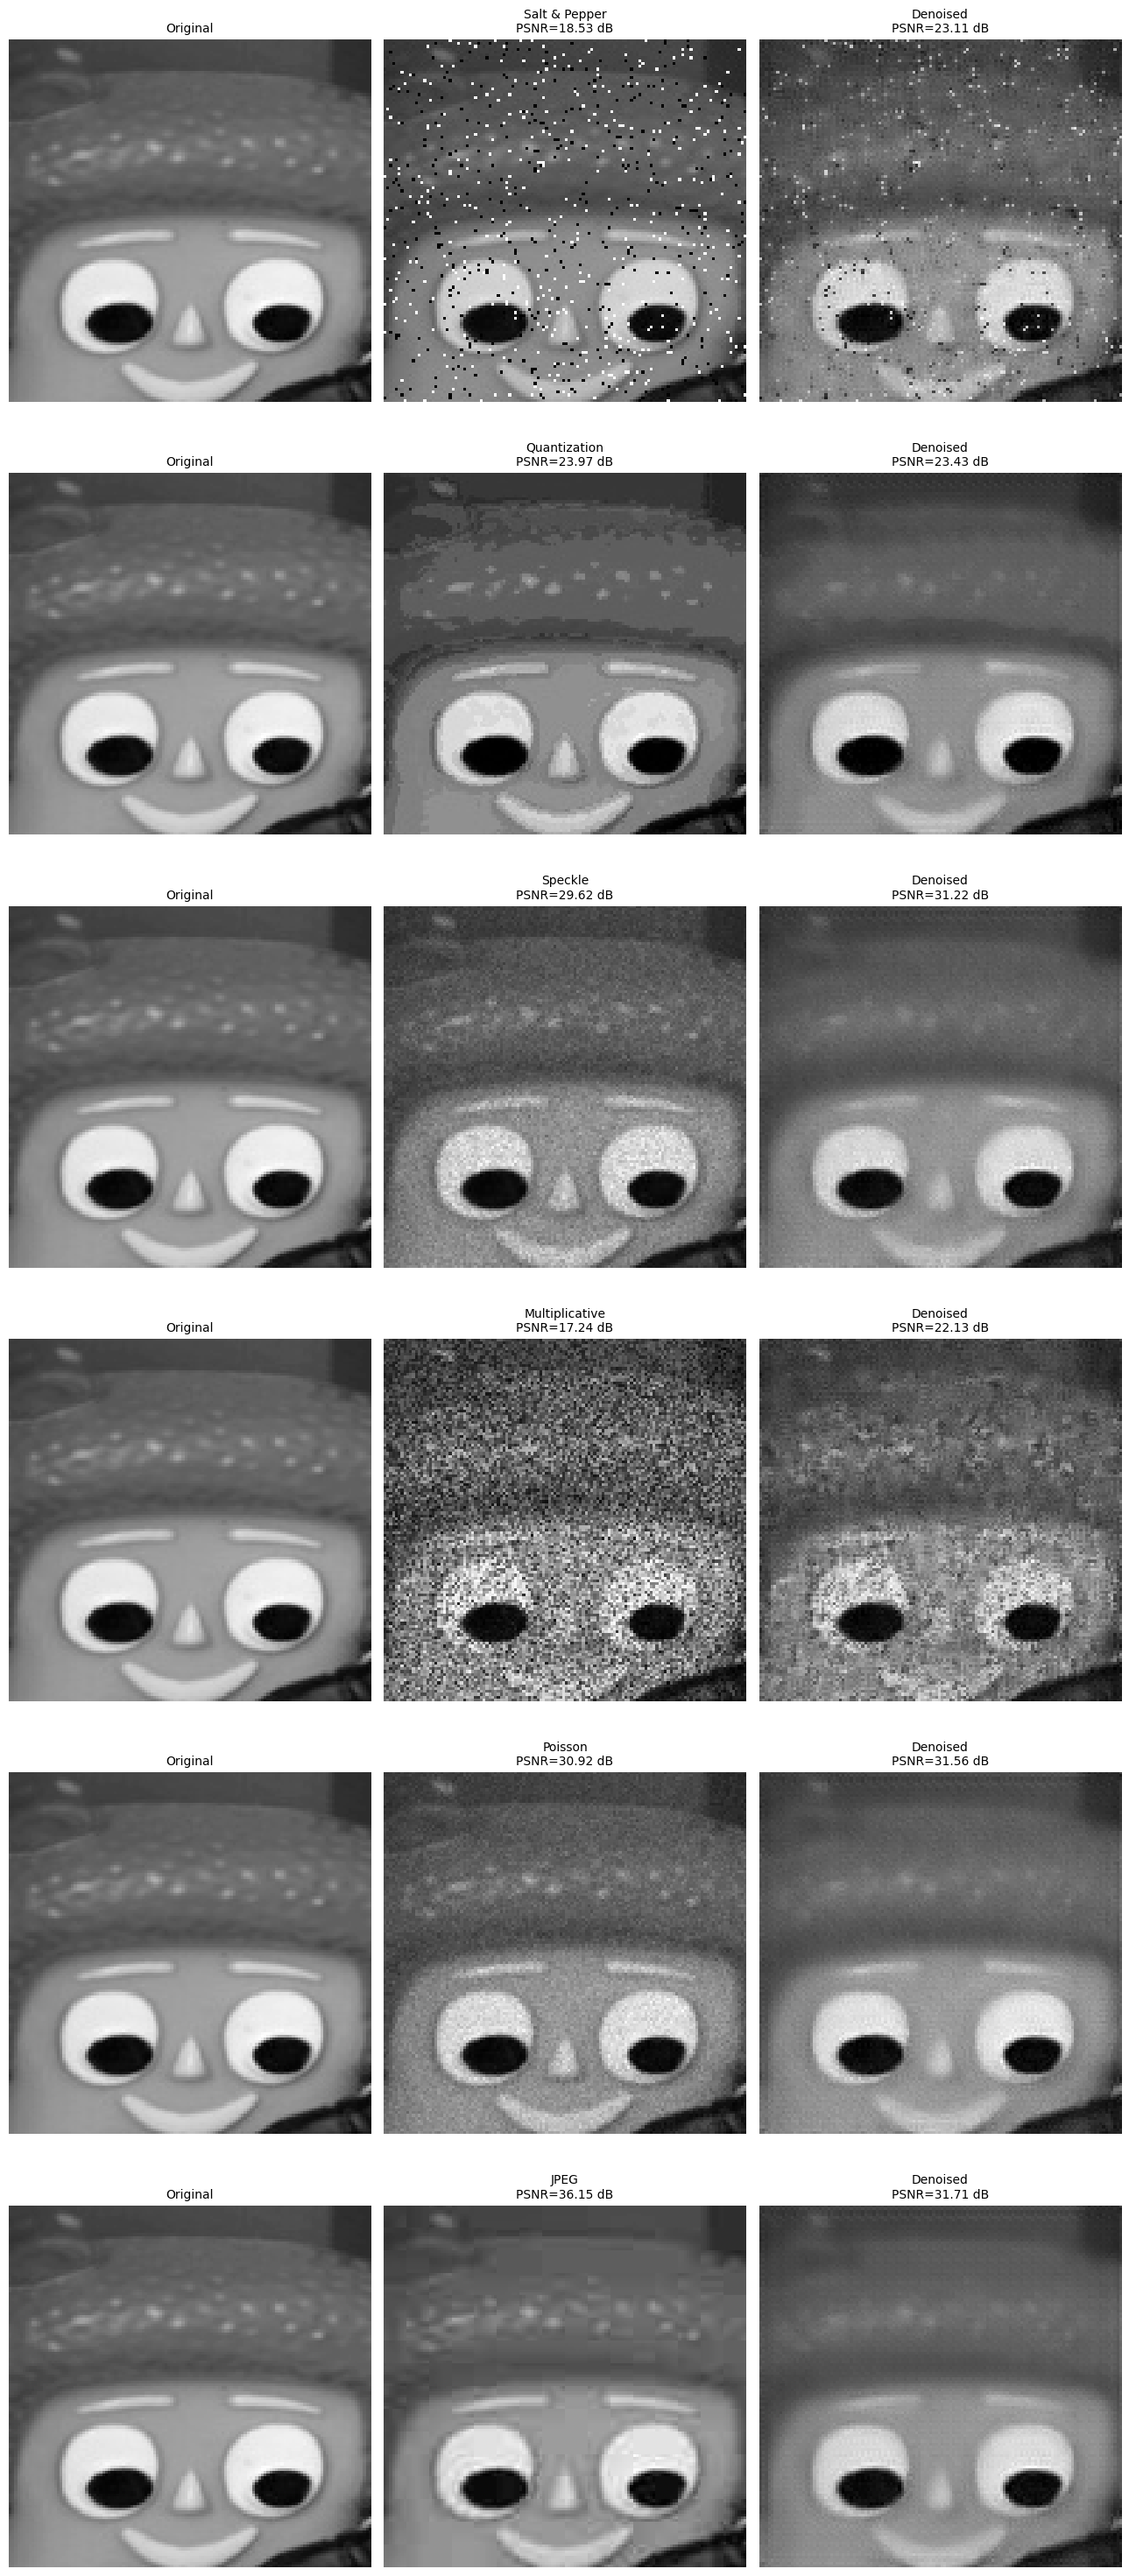

Saved: multi_noise_comparison.png


In [18]:
sample = common[3]
clean  = load_image(orig_path, sample)
clean_np = clean.squeeze().numpy().clip(0, 1)

n_types = len(noise_types)
fig, axes = plt.subplots(n_types, 3, figsize=(13, 5 * n_types))

with torch.no_grad():
    for row, (name, folder) in enumerate(noise_types.items()):
        noisy       = load_image(folder, sample)
        denoised    = model(noisy.unsqueeze(0)).squeeze(0)
        noisy_np    = noisy.squeeze().numpy().clip(0, 1)
        denoised_np = denoised.squeeze().numpy().clip(0, 1)

        psnr_before = compute_psnr(clean_np, noisy_np)
        psnr_after  = compute_psnr(clean_np, denoised_np)

        axes[row][0].imshow(clean_np,    cmap='gray')
        axes[row][0].set_title('Original', fontsize=10)
        axes[row][0].axis('off')

        axes[row][1].imshow(noisy_np,    cmap='gray')
        axes[row][1].set_title(f'{name}\nPSNR={psnr_before:.2f} dB', fontsize=10)
        axes[row][1].axis('off')

        axes[row][2].imshow(denoised_np, cmap='gray')
        axes[row][2].set_title(f'Denoised\nPSNR={psnr_after:.2f} dB', fontsize=10)
        axes[row][2].axis('off')

plt.tight_layout()
plt.savefig('multi_noise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: multi_noise_comparison.png')

## PSNR Improvement Bar Chart

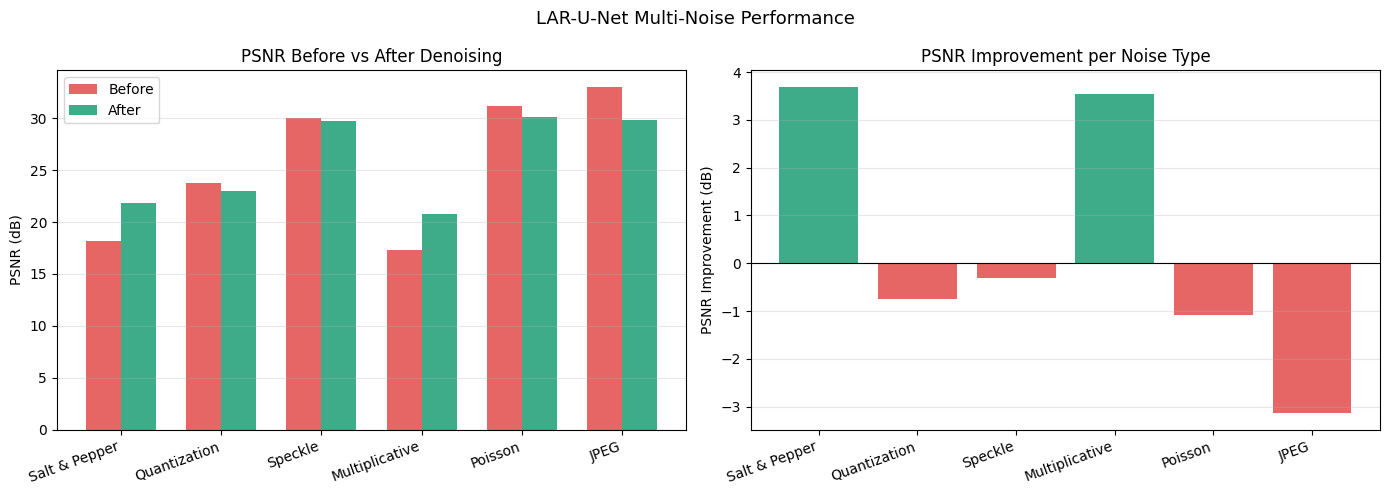

Saved: psnr_chart.png


In [22]:
names        = list(results.keys())
psnr_before  = [np.mean(results[n]["psnr_before"]) for n in names]
psnr_after   = [np.mean(results[n]["psnr_after"])  for n in names]
improvements = [a - b for a, b in zip(psnr_after, psnr_before)]

x   = np.arange(len(names))
w   = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before vs After PSNR
bars1 = ax1.bar(x - w/2, psnr_before, w, label='Before', color='#E24B4A', alpha=0.85)
bars2 = ax1.bar(x + w/2, psnr_after,  w, label='After',  color='#1D9E75', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=20, ha='right')
ax1.set_ylabel('PSNR (dB)')
ax1.set_title('PSNR Before vs After Denoising')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Improvement
colors = ['#1D9E75' if v >= 0 else '#E24B4A' for v in improvements]
ax2.bar(names, improvements, color=colors, alpha=0.85)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=20, ha='right')
ax2.set_ylabel('PSNR Improvement (dB)')
ax2.set_title('PSNR Improvement per Noise Type')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('LAR-U-Net Multi-Noise Performance', fontsize=13)
plt.tight_layout()
plt.savefig('psnr_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: psnr_chart.png')

#Save model & download results


In [23]:
# Save trained model weights
torch.save(model.state_dict(), 'lar_unet_weights.pth')
print('Model saved: lar_unet_weights.pth')

# Download all output files to your computer
from google.colab import files
files.download('loss_curve.png')
files.download('denoised_comparison.png')
files.download('lar_unet_weights.pth')
print('Downloads started.')

Model saved: lar_unet_weights.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started.
